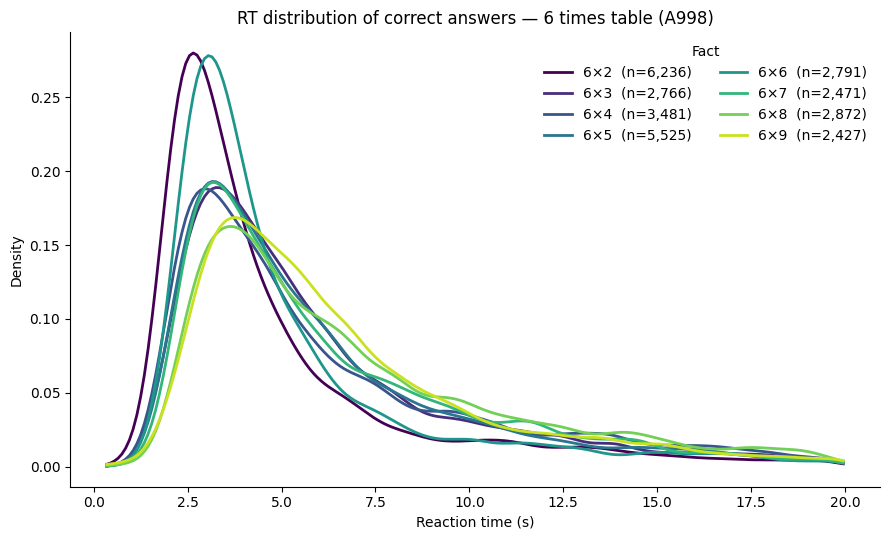

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---------------------------------------------------------------
INFILE  = Path("queries") / "rt_A998_6table_correct.csv"   # columns: operation, rt_seconds
OUTFILE = Path("plots") / "rt_curves_6table_correct.png"
RT_MIN, RT_MAX = 0.3, 20.0    # RT cleaning bounds (s)
BINW      = 0.1               # histogram bin width (s)
SMOOTH_S  = 0.5              # Gaussian smoothing width (s); higher = smoother
FACTS = [f"6X{b}" for b in range(2, 10)]   # 6x2 ... 6x9

# --- load & clean ----------------------------------------------------------
df = pd.read_csv(INFILE)
if "rt_seconds" not in df.columns and "statement_seconds_spent" in df.columns:
    df = df.rename(columns={"statement_seconds_spent": "rt_seconds"})
df = df[df["operation"].isin(FACTS)]
df = df[(df["rt_seconds"] >= RT_MIN) & (df["rt_seconds"] <= RT_MAX)]

# --- smoothed histogram (normalised, Gaussian-convolved) -------------------
def smoothed_density(rt, edges):
    counts, _ = np.histogram(rt, bins=edges, density=True)
    sigma_bins = SMOOTH_S / BINW
    half = int(np.ceil(3 * sigma_bins))
    k = np.arange(-half, half + 1)
    kernel = np.exp(-0.5 * (k / sigma_bins) ** 2); kernel /= kernel.sum()
    return np.convolve(counts, kernel, mode="same")

edges   = np.arange(RT_MIN, RT_MAX + BINW, BINW)
centers = (edges[:-1] + edges[1:]) / 2
colors  = plt.cm.viridis(np.linspace(0, 0.92, len(FACTS)))

# --- plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
for fact, color in zip(FACTS, colors):
    rt = df.loc[df["operation"] == fact, "rt_seconds"].to_numpy()
    if rt.size < 5:
        continue
    ax.plot(centers, smoothed_density(rt, edges), color=color, lw=2,
            label=fact.replace("X", "×") + f"  (n={rt.size:,})")

ax.set_xlabel("Reaction time (s)")
ax.set_ylabel("Density")
ax.set_title("RT distribution of correct answers — 6 times table (A998)")
ax.legend(title="Fact", frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)   # no xlim: autoscale

OUTFILE.parent.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(OUTFILE, dpi=150)
plt.show()

## Log-normal test

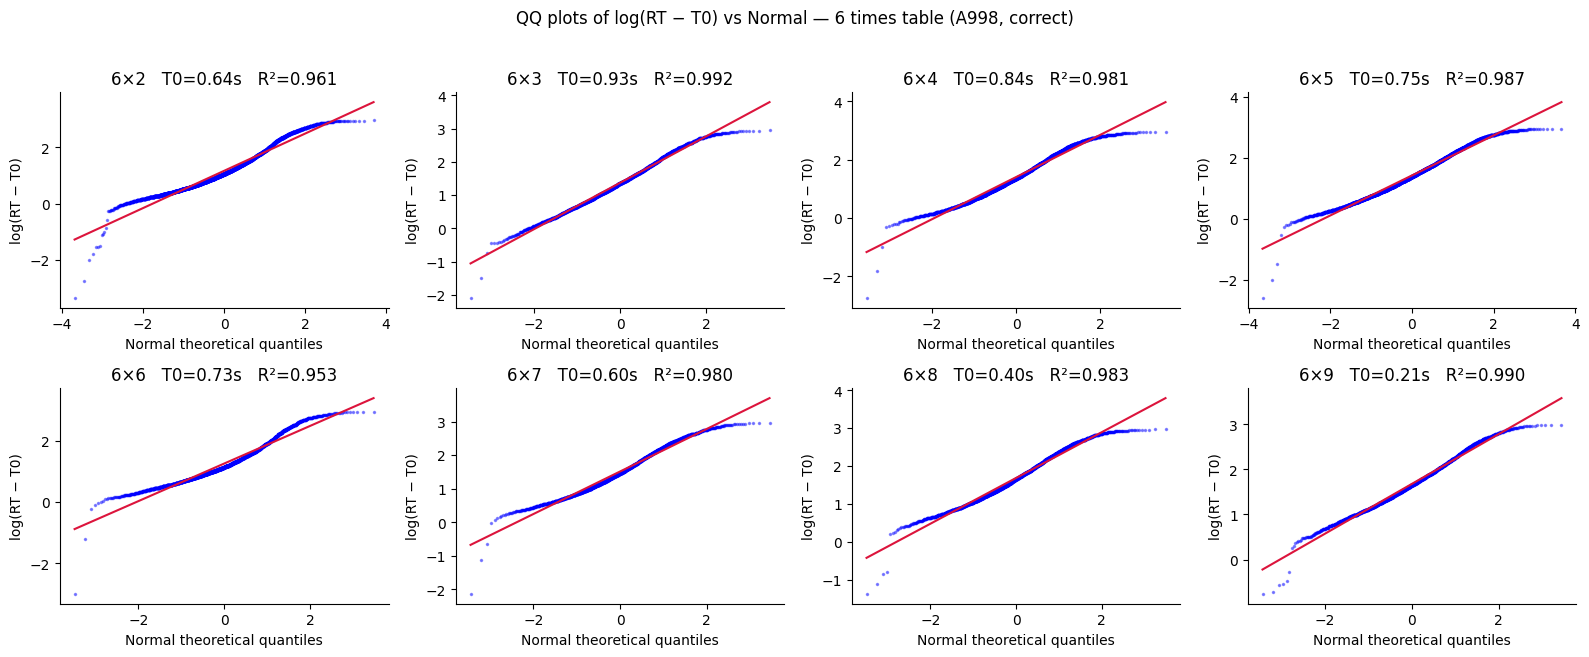

In [3]:
from scipy import stats

facts_present = [f for f in FACTS if (df["operation"] == f).sum() >= 20]
ncol = 4
nrow = int(np.ceil(len(facts_present) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow))
axes = np.array(axes).ravel()

for ax, fact in zip(axes, facts_present):
    rt = df.loc[df["operation"] == fact, "rt_seconds"].to_numpy()

    # onset T0: reuse the fit from the previous cell if it exists, else fit here.
    if "fits" in globals() and fact in fits:
        T0 = fits[fact].kwds["loc"]
    else:
        _, T0, _ = stats.lognorm.fit(rt)

    y = np.log(rt - T0)                      # should be ~Normal if RT is shifted-lognormal
    (osm, osr), (slope, icpt, r) = stats.probplot(y, dist="norm", plot=ax)

    ax.get_lines()[0].set(marker=".", markersize=3, alpha=0.4)   # data points
    ax.get_lines()[1].set(color="crimson", lw=1.5)               # reference line
    ax.set_title(f"{fact.replace('X', '×')}   T0={T0:.2f}s   R²={r**2:.3f}")
    ax.set_xlabel("Normal theoretical quantiles")
    ax.set_ylabel("log(RT − T0)")
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(facts_present):]:         # hide unused panels
    ax.set_visible(False)

fig.suptitle("QQ plots of log(RT − T0) vs Normal — 6 times table (A998, correct)", y=1.02)
fig.tight_layout()
plt.show()

## Log-logistic check

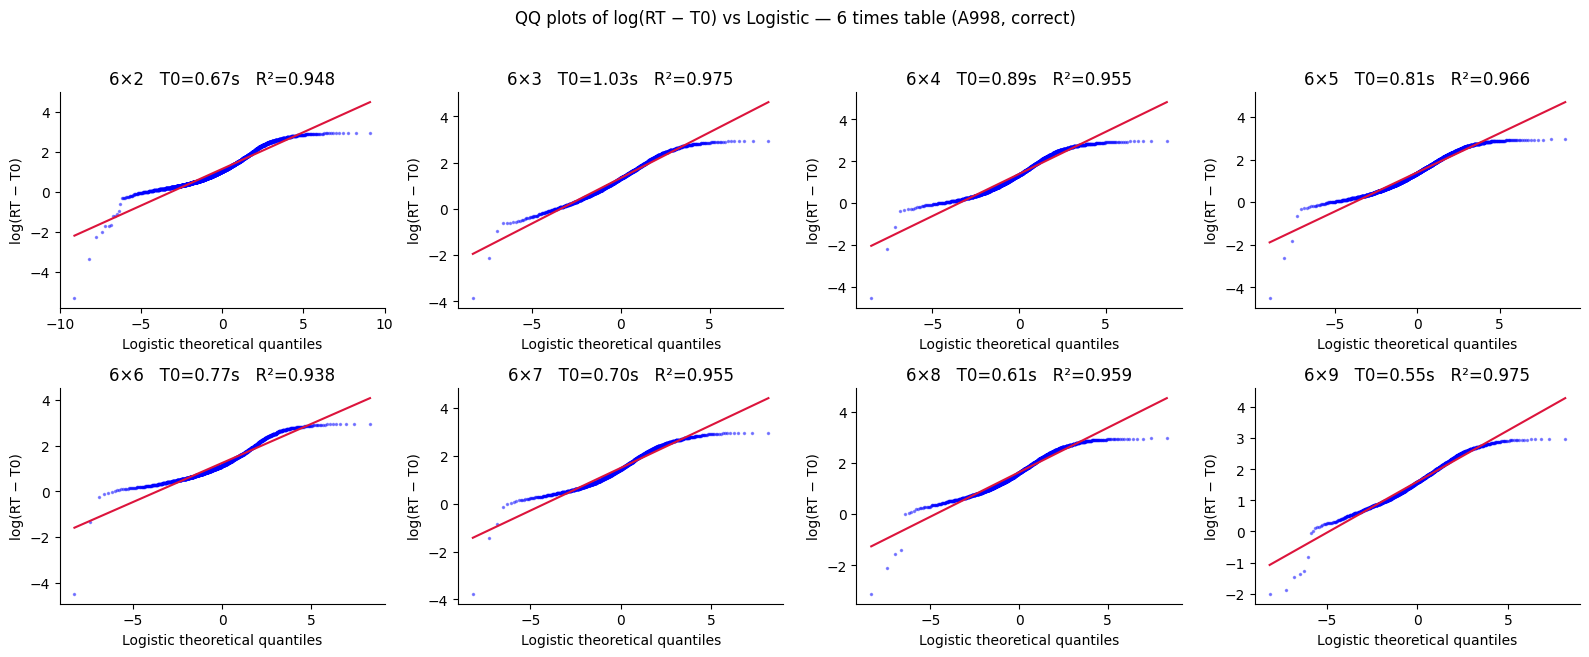

In [4]:
from scipy import stats

facts_present = [f for f in FACTS if (df["operation"] == f).sum() >= 20]
ncol = 4
nrow = int(np.ceil(len(facts_present) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow))
axes = np.array(axes).ravel()

fits_ll = {}
for ax, fact in zip(axes, facts_present):
    rt = df.loc[df["operation"] == fact, "rt_seconds"].to_numpy()

    # log-logistic (Fisk) fit; loc is the onset T0, fit per fact.
    c, T0, scale = stats.fisk.fit(rt)
    fits_ll[fact] = stats.fisk(c, loc=T0, scale=scale)

    y = np.log(rt - T0)                      # ~Logistic if RT is shifted log-logistic
    (osm, osr), (slope, icpt, r) = stats.probplot(y, dist="logistic", plot=ax)

    ax.get_lines()[0].set(marker=".", markersize=3, alpha=0.4)   # data points
    ax.get_lines()[1].set(color="crimson", lw=1.5)               # reference line
    ax.set_title(f"{fact.replace('X', '×')}   T0={T0:.2f}s   R²={r**2:.3f}")
    ax.set_xlabel("Logistic theoretical quantiles")
    ax.set_ylabel("log(RT − T0)")
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(facts_present):]:         # hide unused panels
    ax.set_visible(False)

fig.suptitle("QQ plots of log(RT − T0) vs Logistic — 6 times table (A998, correct)", y=1.02)
fig.tight_layout()
plt.show()

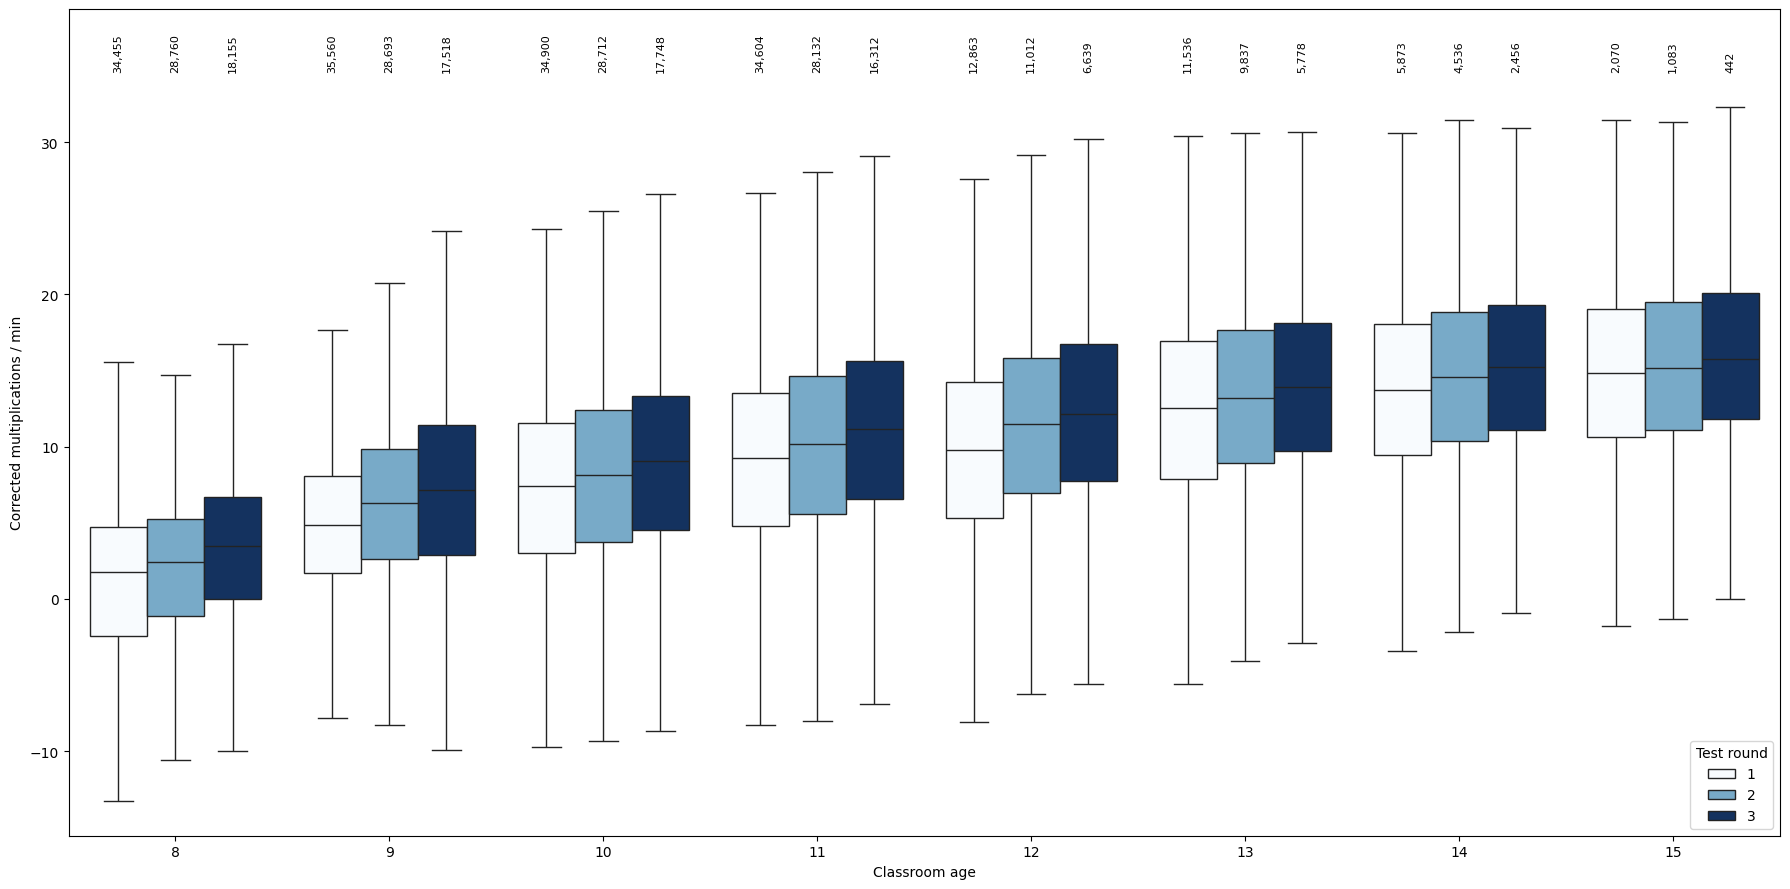

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("queries/a998_corrected_mult_per_min.csv")
df["test_round"] = df["test_round"].astype(int)
df = df[df["classroom_age"] >= 8]        # only ages 8 and beyond

ages = sorted(df["classroom_age"].unique())
rounds = sorted(df["test_round"].unique())
n_hue = len(rounds)

fig, ax = plt.subplots(figsize=(18, 9))
sns.boxplot(data=df, x="classroom_age", y="corrected_per_min", palette="Blues", hue="test_round",
            order=ages, hue_order=rounds, showfliers=False, ax=ax)

counts = df.groupby(["classroom_age", "test_round"]).size()
box_width = 0.8 / n_hue
y_top = ax.get_ylim()[1]
for i, age in enumerate(ages):
    for j, rnd in enumerate(rounds):
        n = counts.get((age, rnd), 0)
        x = i + (j - (n_hue - 1) / 2) * box_width
        ax.text(x, y_top, f"{n:,}", ha="center", va="bottom",
                fontsize=8, rotation=90, color="black")

ax.set_ylim(top=y_top * 1.12)
ax.set_xlabel("Classroom age")
ax.set_ylabel("Corrected multiplications / min")
ax.legend(title="Test round")
plt.tight_layout()
plt.savefig("plots/a998_corrected_mult_per_min_boxplot.png", dpi=150)
plt.show()

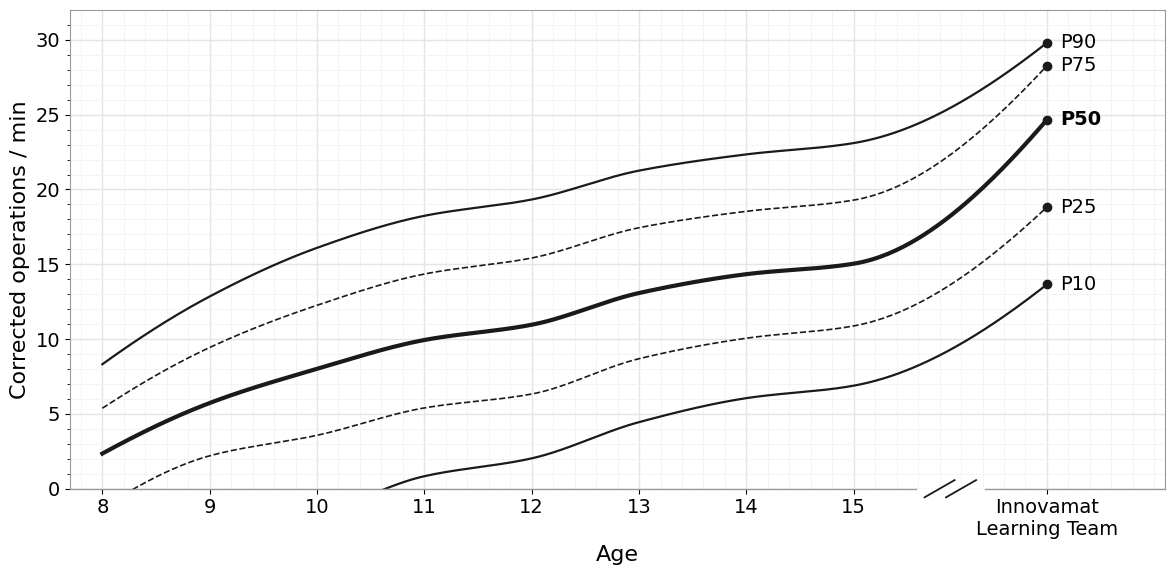

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["font.size"] = 15                       # base font size

pcts = [10, 25, 50, 75, 90]
style = {10: (1.6, "-"), 90: (1.6, "-"), 50: (3.0, "-"), 25: (1.2, "--"), 75: (1.2, "--")}

# --- student percentiles by age (ages 8–15) ---
df = pd.read_csv("queries/a998_corrected_mult_per_min.csv")
df = df[(df["classroom_age"] >= 8) & (df["classroom_age"] <= 15)]
ages = np.array(sorted(df["classroom_age"].unique()))
table = (df.groupby("classroom_age")["corrected_per_min"]
           .apply(lambda s: np.percentile(s, pcts)).reindex(ages))
P = {p: np.array([table.loc[a][i] for a in ages]) for i, p in enumerate(pcts)}

# --- adult reference (Innovamat Learning Team) ---
lt = pd.read_csv("queries/learning_team_per_min.csv")
adult = {p: np.percentile(lt["corrected_per_min"], p) for p in pcts}
x_adult = ages.max() + 1.8

# append the adult node and smooth across the whole span so curves flow into it
ages_ext = np.append(ages, x_adult)
grid = np.linspace(ages.min(), x_adult, 400)
Psm = {p: PchipInterpolator(ages_ext, np.append(P[p], adult[p]))(grid) for p in pcts}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")

for p in pcts:
    lw, ls = style[p]
    ax.plot(grid, Psm[p], color="#1a1a1a", linewidth=lw, linestyle=ls)
    ax.plot(x_adult, adult[p], "o", color="#1a1a1a", markersize=6)
    ax.text(x_adult + 0.12, adult[p], f"P{p}", va="center", ha="left",
            fontsize=14, fontweight="bold" if p == 50 else "normal")

ax.set_xticks(list(ages) + [x_adult])
ax.set_xticklabels([str(a) for a in ages] + ["Innovamat\nLearning Team"])
ax.tick_params(axis="both", labelsize=14)
ax.grid(which="major", color="#E5E5E5", linewidth=1.0)
ax.minorticks_on(); ax.grid(which="minor", color="#F2F2F2", linewidth=0.6)
ax.tick_params(which="minor", bottom=False)

xlo, xhi = ages.min() - 0.3, x_adult + 1.1
ax.set_xlim(xlo, xhi); ax.set_ylim(bottom=0)
for s in ax.spines.values():
    s.set_color("#999999")

# --- break the BOTTOM spine only (top frame line stays continuous), add // marks ---
x_break = ages.max() + 0.9
half = 0.32                          # half-width of the spine gap (data units)
trans = ax.get_xaxis_transform()     # x = data, y = axes fraction (0 bottom, 1 top)
ax.spines["bottom"].set_visible(False)
ax.plot([xlo, x_break - half], [0, 0], transform=trans, color="#999999", lw=1.0, clip_on=False)
ax.plot([x_break + half, xhi], [0, 0], transform=trans, color="#999999", lw=1.0, clip_on=False)
dx, dy, gap = 0.14, 0.018, 0.10      # the // marks straddling the bottom gap
for off in (-gap, gap):
    ax.plot([x_break + off - dx, x_break + off + dx], [-dy, dy],
            transform=trans, color="#1a1a1a", lw=1.3, clip_on=False, zorder=5)

ax.set_xlabel("Age", fontsize=16)
ax.set_ylabel("Corrected operations / min", fontsize=16)
#ax.set_title("A998 — Arithmetic fluency percentiles by age, vs adult reference", fontsize=17, loc="left")

plt.tight_layout()
plt.savefig("plots/a998_percentile_curves_adult.png", dpi=600)
plt.savefig("plots/a998_percentile_curves_adult.pdf")
plt.show()